/tmp/ipykernel_7933/4286327832.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2018-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0233 - val_loss: 9.4037e-04
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 5.7854e-04 - val_loss: 0.0010
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 4.8147e-04 - val_loss: 0.0012
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 4.6689e-04 - val_loss: 9.8654e-04
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 4.7592e-04 - val_loss: 0.0012
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 5.2204e-04 - val_loss: 0.0014
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 4.4656e-04 - val_loss: 0.0011
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 4.0937e-04 - val_loss: 0.0010
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 3.9677e-04 - val_loss: 7.6426e-04
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 3.8837e-04 - val_loss: 7.5648e-04
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 3.8174e-04 - val_loss: 6.8765e-04
Epo

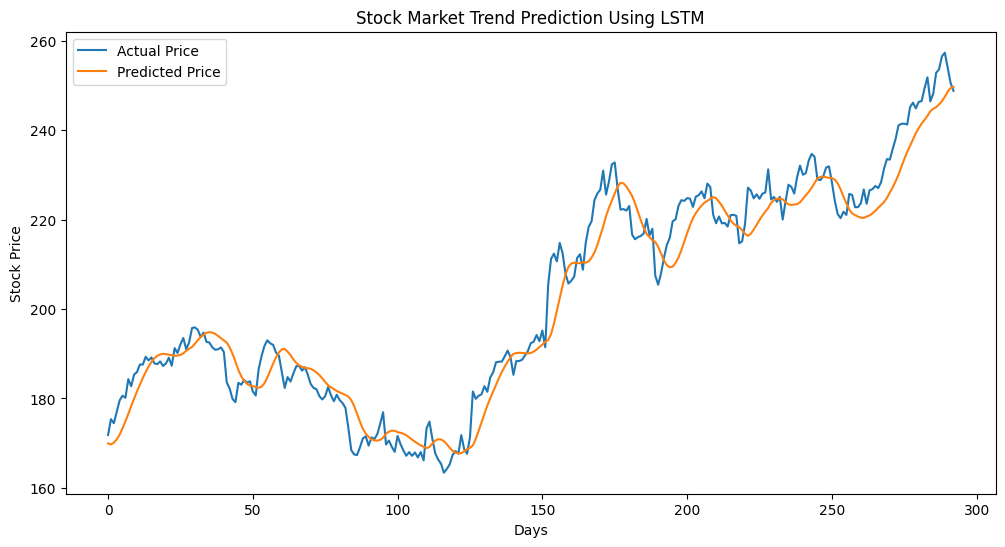

RMSE: 5.440034774086105


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Download Stock Data
df = yf.download("AAPL", start="2018-01-01", end="2025-01-01")

data = df[['Close']]

# Scaling
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# Train Test Split
train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Create Sequences
def create_dataset(dataset, time_step=60):
    X, y = [], []

    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

time_step = 60

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Reshape for LSTM
X_train = X_train.reshape(X_train.shape[0],
                          X_train.shape[1], 1)

X_test = X_test.reshape(X_test.shape[0],
                        X_test.shape[1], 1)

# Build LSTM Model
model = Sequential()

model.add(LSTM(50,
               return_sequences=True,
               input_shape=(X_train.shape[1],1)))

model.add(LSTM(50))

model.add(Dense(25))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Predictions
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

# Plot Results
plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual Price")

plt.plot(predictions,
         label="Predicted Price")

plt.title("Stock Market Trend Prediction Using LSTM")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

# RMSE
rmse = np.sqrt(
    np.mean(
        (actual - predictions)**2
    )
)

print("RMSE:", rmse)